## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each LAU1 Unit ##

In [4]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'utf-8'

random.seed(0)
np.random.seed(0)

In [5]:
NUTS0 = 'IT'
NUTS2 = 'Veneto'
NUTS2_LOWER = 'veneto'

In [6]:
## Reading shapefiles from Italy
folder_path = "C:/Users/dimit/Documents/noa hoard/Italy Shapefiles"

italy_gdf = gpd.read_file(f"{folder_path}\italy.shp")
rivers_gdf = gpd.read_file(f"{folder_path}\waterways.shp")

In [7]:
italy_gdf.head()

,FID,COD_RIP,COD_REG,COD_PROV,COD_CM,COD_UTS,PRO_COM,PRO_COM_T,COMUNE,COMUNE_A,CC_UTS,SHAPE_LENG,GlobalID,SHAPE_Le_1,SHAPE_Area,geometry
0,1,1,1,1,201,201,1042,001042,Burolo,None,0,13222.896787,{428A5371-1203-4014-9D3B-D6F2353A226F},0.141254,5.475974e+06,"POLYGON ((7.93812 45.49086, 7.93818 45.49034, ..."
1,2,1,1,1,201,201,1060,001060,Casalborgone,None,0,24056.822202,{7772511B-1529-4A71-8ED1-7880DC64354A},0.270078,2.012501e+07,"POLYGON ((7.91362 45.15298, 7.91369 45.15297, ..."
2,3,1,1,1,201,201,1076,001076,Chianocco,None,0,21411.076163,{0F2EE4C5-219C-43DD-AD6E-D8AE5E9F5F7B},0.225795,1.861335e+07,"POLYGON ((7.18303 45.19351, 7.18342 45.19309, ..."
3,4,1,1,1,201,201,1077,001077,Chiaverano,None,0,18164.369945,{16E8325A-C7CD-4B85-AB7D-74216B9D06B3},0.196687,1.202212e+07,"POLYGON ((7.90330 45.52628, 7.90360 45.52626, ..."
4,5,1,1,1,201,201,1079,001079,Chiesanuova,None,0,10777.398475,{8FF28D8A-C5F5-4214-AFA0-999D470CF9C8},0.116011,4.118911e+06,"POLYGON ((7.65285 45.42981, 7.65407 45.42951, ..."


<AxesSubplot:>

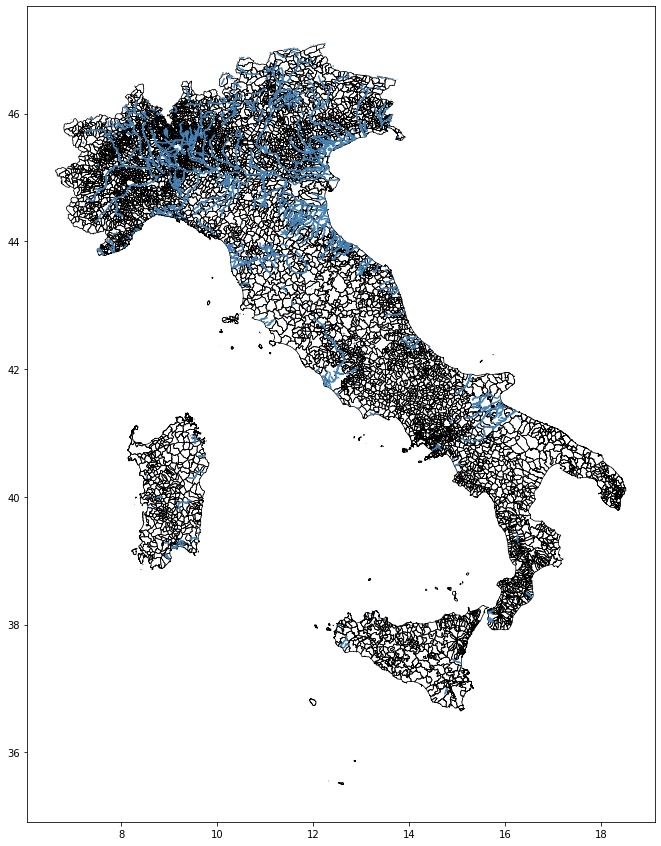

In [8]:
ax = rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
italy_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [9]:
nuts2_gdf = italy_gdf.loc[italy_gdf['COD_REG'] == 5].copy()
nuts2_gdf.head()

,FID,COD_RIP,COD_REG,COD_PROV,COD_CM,COD_UTS,PRO_COM,PRO_COM_T,COMUNE,COMUNE_A,CC_UTS,SHAPE_LENG,GlobalID,SHAPE_Le_1,SHAPE_Area,geometry
114,115,2,5,24,0,24,24070,024070,Mussolente,None,0,21396.915642,{F056368A-60F4-4355-8392-18A40FA049CD},0.229581,1.543081e+07,"POLYGON ((11.79414 45.79929, 11.79464 45.79910..."
115,116,2,5,24,0,24,24035,024035,Costabissara,None,0,19751.461429,{56C62B6B-0532-4D4F-9198-B37BEBC92AB6},0.218976,1.313203e+07,"POLYGON ((11.48958 45.60955, 11.48971 45.60951..."
121,122,2,5,23,0,23,23001,023001,Affi,None,0,16409.933361,{2C8E0DB3-E06F-4162-B4AA-C0A51D9F6FCB},0.181871,9.881361e+06,"POLYGON ((10.78164 45.57539, 10.78274 45.57519..."
122,123,2,5,23,0,23,23002,023002,Albaredo d'Adige,None,0,27907.866591,{ADE3DB5E-240F-4D44-893D-656EC25230D4},0.310924,2.825321e+07,"POLYGON ((11.28596 45.33269, 11.28734 45.33242..."
123,124,2,5,23,0,23,23003,023003,Angiari,None,0,18600.917222,{AAC2D671-079A-46E7-84B0-24C7E4A99F5C},0.201585,1.347062e+07,"POLYGON ((11.26925 45.24528, 11.27031 45.24443..."


<AxesSubplot:>

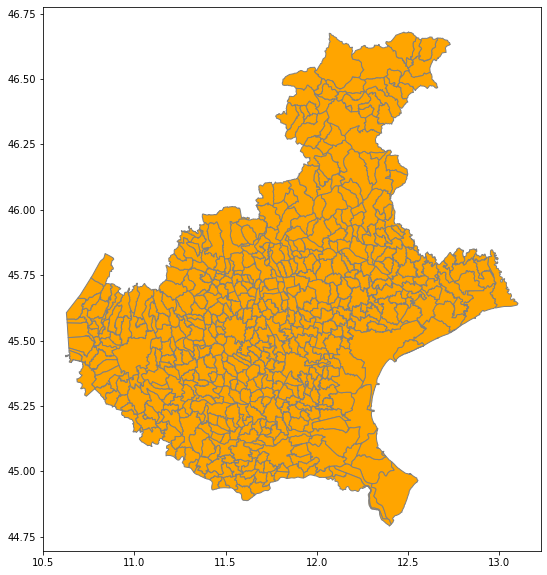

In [10]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [11]:
nuts2_gdf.drop(columns=['FID', 'COD_RIP', 'COD_REG', 'COD_PROV', 'COD_CM', 'COD_UTS', 'PRO_COM', 'PRO_COM_T', 'COMUNE_A', 'CC_UTS' ,'SHAPE_LENG', 'GlobalID', 'SHAPE_Le_1'], inplace = True)
nuts2_gdf.rename(columns={"COMUNE": "lau1", "SHAPE_Area" : "area"}, inplace = True)
process_italic(nuts2_gdf, 'lau1')

In [12]:
nuts2_gdf.head(5)

,lau1,area,geometry
114,mussolente,1.543081e+07,"POLYGON ((11.79414 45.79929, 11.79464 45.79910..."
115,costabissara,1.313203e+07,"POLYGON ((11.48958 45.60955, 11.48971 45.60951..."
121,affi,9.881361e+06,"POLYGON ((10.78164 45.57539, 10.78274 45.57519..."
122,albaredo da adige,2.825321e+07,"POLYGON ((11.28596 45.33269, 11.28734 45.33242..."
123,angiari,1.347062e+07,"POLYGON ((11.26925 45.24528, 11.27031 45.24443..."


In [13]:
indexes = []

nuts2 = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [14]:
nuts2_rivers_gdf.head()

,osm_id,name,type,width,geometry
0,4478117,Rio Nuovo,canal,8,"LINESTRING (12.32009 45.43708, 12.32009 45.437..."
1,4478118,None,canal,8,"LINESTRING (12.32019 45.43641, 12.32092 45.436..."
2,4478168,Rio de San Trovaso,canal,10,"LINESTRING (12.32563 45.42955, 12.32592 45.430..."
3,4478935,RIO DE S. MARGHERITA,canal,8,"LINESTRING (12.32317 45.43541, 12.32310 45.434..."
4,4479144,None,canal,8,"LINESTRING (12.33380 45.42536, 12.33335 45.42315)"


<AxesSubplot:>

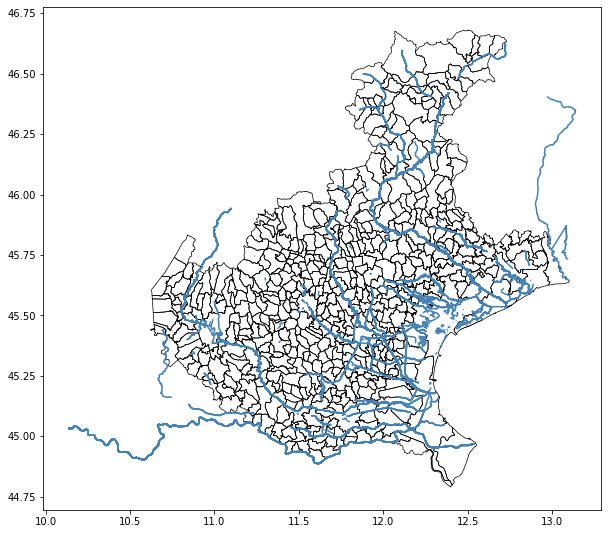

In [15]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(10, 10), cmap='jet', color='steelblue')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [16]:
lau1_units = nuts2_gdf['lau1'].unique().tolist()

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_LAU1_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in lau1_units:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in {NUTS2} (from shapefile): {len(lau1_units)}")

Number of LAU1 Units in Veneto (from shapefile): 571


In [17]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [54]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='lau1', dimension=2.5)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Drive\NOA\MBD-Prediction\Italy\notebooks\Veneto\../../../Modules\utils.py:735: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 

In [55]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

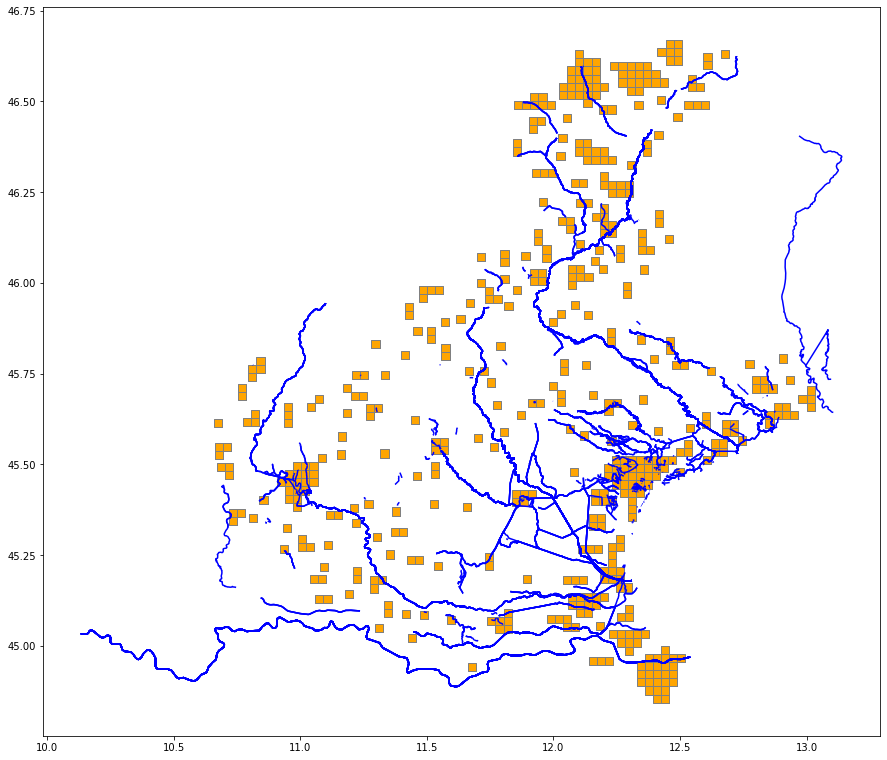

In [56]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [57]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 160


['mussolente', 'costabissara', 'affi', 'angiari', 'arcole', 'creazzo', 'sanguinetto', 'saint martino buon albergo', 'saint mauro da saline', 'soave', 'saint gregorio nelle alpi', 'quinto da treviso', 'refrontolo', 'cibiana da cadore', 'sossano', 'sovizzo', 'saint nicolo da comelico', 'meduna da livenza', 'conegliano', 'ponte da piave', 'monastier da treviso', 'sandrigo', 'colle saint lucia', 'carbonera', 'ponzano veneto', 'portobuffole', 'arqua petrarca', 'barbarano mossano', 'crespano da grappa', 'crocetta da montello', 'moriago da battaglia', 'rotzo', 'salcedo', 'monfumo', 'curtarolo', 'este', 'masera da padova', 'masi', 'massanzago', 'ceregnano', 'corbola', 'saint martino da venezze', 'stienta', 'cervarese saint croce', 'cinto euganeo', 'rubano', 'teglio veneto', 'torre da mosto', 'nervesa da battaglia', 'morgano', 'solagna', 'villanova da camposampiero', 'vo', 'due carrare', 'arqua polesine', 'costermano sul garda', 'romano da ezzelino', 'saint tomaso agordino', 'valdastico', 'lent

C:\Users\dimit\AppData\Local\Temp/ipykernel_13056/839959091.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_lau1["centroid"] = lost_lau1["geometry"].centroid
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


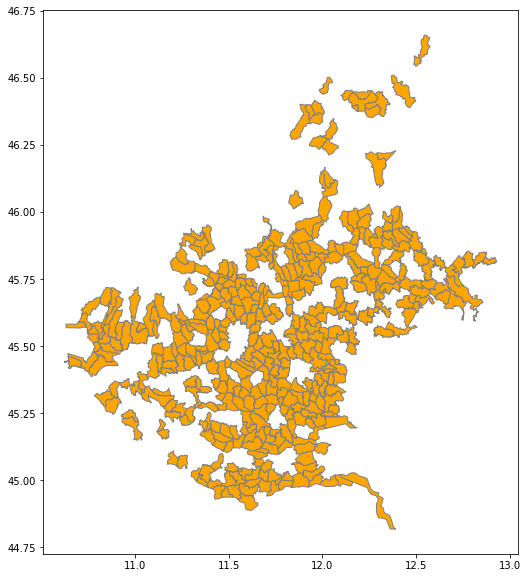

In [58]:
if (len(lau1_units) != len(grid_lau1)):
    delta = [item for item in lau1_units if item not in grid_lau1]
    print(delta)

    lost_lau1 = nuts2_gdf[nuts2_gdf['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['lau1'] = lost_lau1['lau1']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [59]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [60]:
nuts2_grid

,geometry,lau1,x,y
0,"POLYGON ((11.31808 45.28770, 11.31808 45.31016...",albaredo da adige,11.30213,45.29893
1,"POLYGON ((11.20247 45.63108, 11.20247 45.65353...",crespadoro,11.18641,45.64230
2,"POLYGON ((10.87121 45.38996, 10.87121 45.41242...",sommacampagna,10.85523,45.40119
3,"POLYGON ((11.29043 45.62090, 11.29043 45.64336...",valdagno,11.27438,45.63213
4,"POLYGON ((11.29043 45.64336, 11.29043 45.66582...",valdagno,11.27438,45.65459
...,...,...,...,...
487,"POLYGON ((12.18313 46.35080, 12.18313 46.37326...",val da zoldo,12.16688,46.36203
488,"POLYGON ((12.21563 46.32834, 12.21563 46.35080...",val da zoldo,12.19938,46.33957
489,"POLYGON ((12.21563 46.35080, 12.21563 46.37326...",val da zoldo,12.19938,46.36203
490,"POLYGON ((12.24812 46.32834, 12.24812 46.35080...",val da zoldo,12.23187,46.33957


In [61]:
if (len(lau1_units) != len(grid_lau1)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [62]:
nuts2_grid['nuts2'] = NUTS2_LOWER

In [63]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [64]:
nuts2_grid

,shape,lau1,x,y,nuts2
0,"POLYGON ((11.31808 45.28770, 11.31808 45.31016...",albaredo da adige,11.30213,45.29893,veneto
1,"POLYGON ((11.20247 45.63108, 11.20247 45.65353...",crespadoro,11.18641,45.64230,veneto
2,"POLYGON ((10.87121 45.38996, 10.87121 45.41242...",sommacampagna,10.85523,45.40119,veneto
3,"POLYGON ((11.29043 45.62090, 11.29043 45.64336...",valdagno,11.27438,45.63213,veneto
4,"POLYGON ((11.29043 45.64336, 11.29043 45.66582...",valdagno,11.27438,45.65459,veneto
...,...,...,...,...,...
898,"POLYGON ((11.19826 45.25346, 11.19861 45.25216...",saint pietro da morubio,11.20096,45.24276,veneto
899,"POLYGON ((12.06082 46.33488, 12.06161 46.33485...",agordo,12.04755,46.30297,veneto
900,"POLYGON ((11.75146 45.87320, 11.75260 45.87308...",pove da grappa,11.73823,45.83013,veneto
901,"POLYGON ((11.68538 45.70087, 11.68542 45.70001...",pozzoleone,11.67640,45.66637,veneto


In [65]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [66]:
nuts2_grid_points

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((11.31808 45.28770, 11.31808 45.31016...",albaredo da adige,11.30213,45.29893,veneto,POINT (11.30213 45.29893)
1,"POLYGON ((11.20247 45.63108, 11.20247 45.65353...",crespadoro,11.18641,45.64230,veneto,POINT (11.18641 45.64230)
2,"POLYGON ((10.87121 45.38996, 10.87121 45.41242...",sommacampagna,10.85523,45.40119,veneto,POINT (10.85523 45.40119)
3,"POLYGON ((11.29043 45.62090, 11.29043 45.64336...",valdagno,11.27438,45.63213,veneto,POINT (11.27438 45.63213)
4,"POLYGON ((11.29043 45.64336, 11.29043 45.66582...",valdagno,11.27438,45.65459,veneto,POINT (11.27438 45.65459)
...,...,...,...,...,...,...
898,"POLYGON ((11.19826 45.25346, 11.19861 45.25216...",saint pietro da morubio,11.20096,45.24276,veneto,POINT (11.20096 45.24276)
899,"POLYGON ((12.06082 46.33488, 12.06161 46.33485...",agordo,12.04755,46.30297,veneto,POINT (12.04755 46.30297)
900,"POLYGON ((11.75146 45.87320, 11.75260 45.87308...",pove da grappa,11.73823,45.83013,veneto,POINT (11.73823 45.83013)
901,"POLYGON ((11.68538 45.70087, 11.68542 45.70001...",pozzoleone,11.67640,45.66637,veneto,POINT (11.67640 45.66637)


<AxesSubplot:>

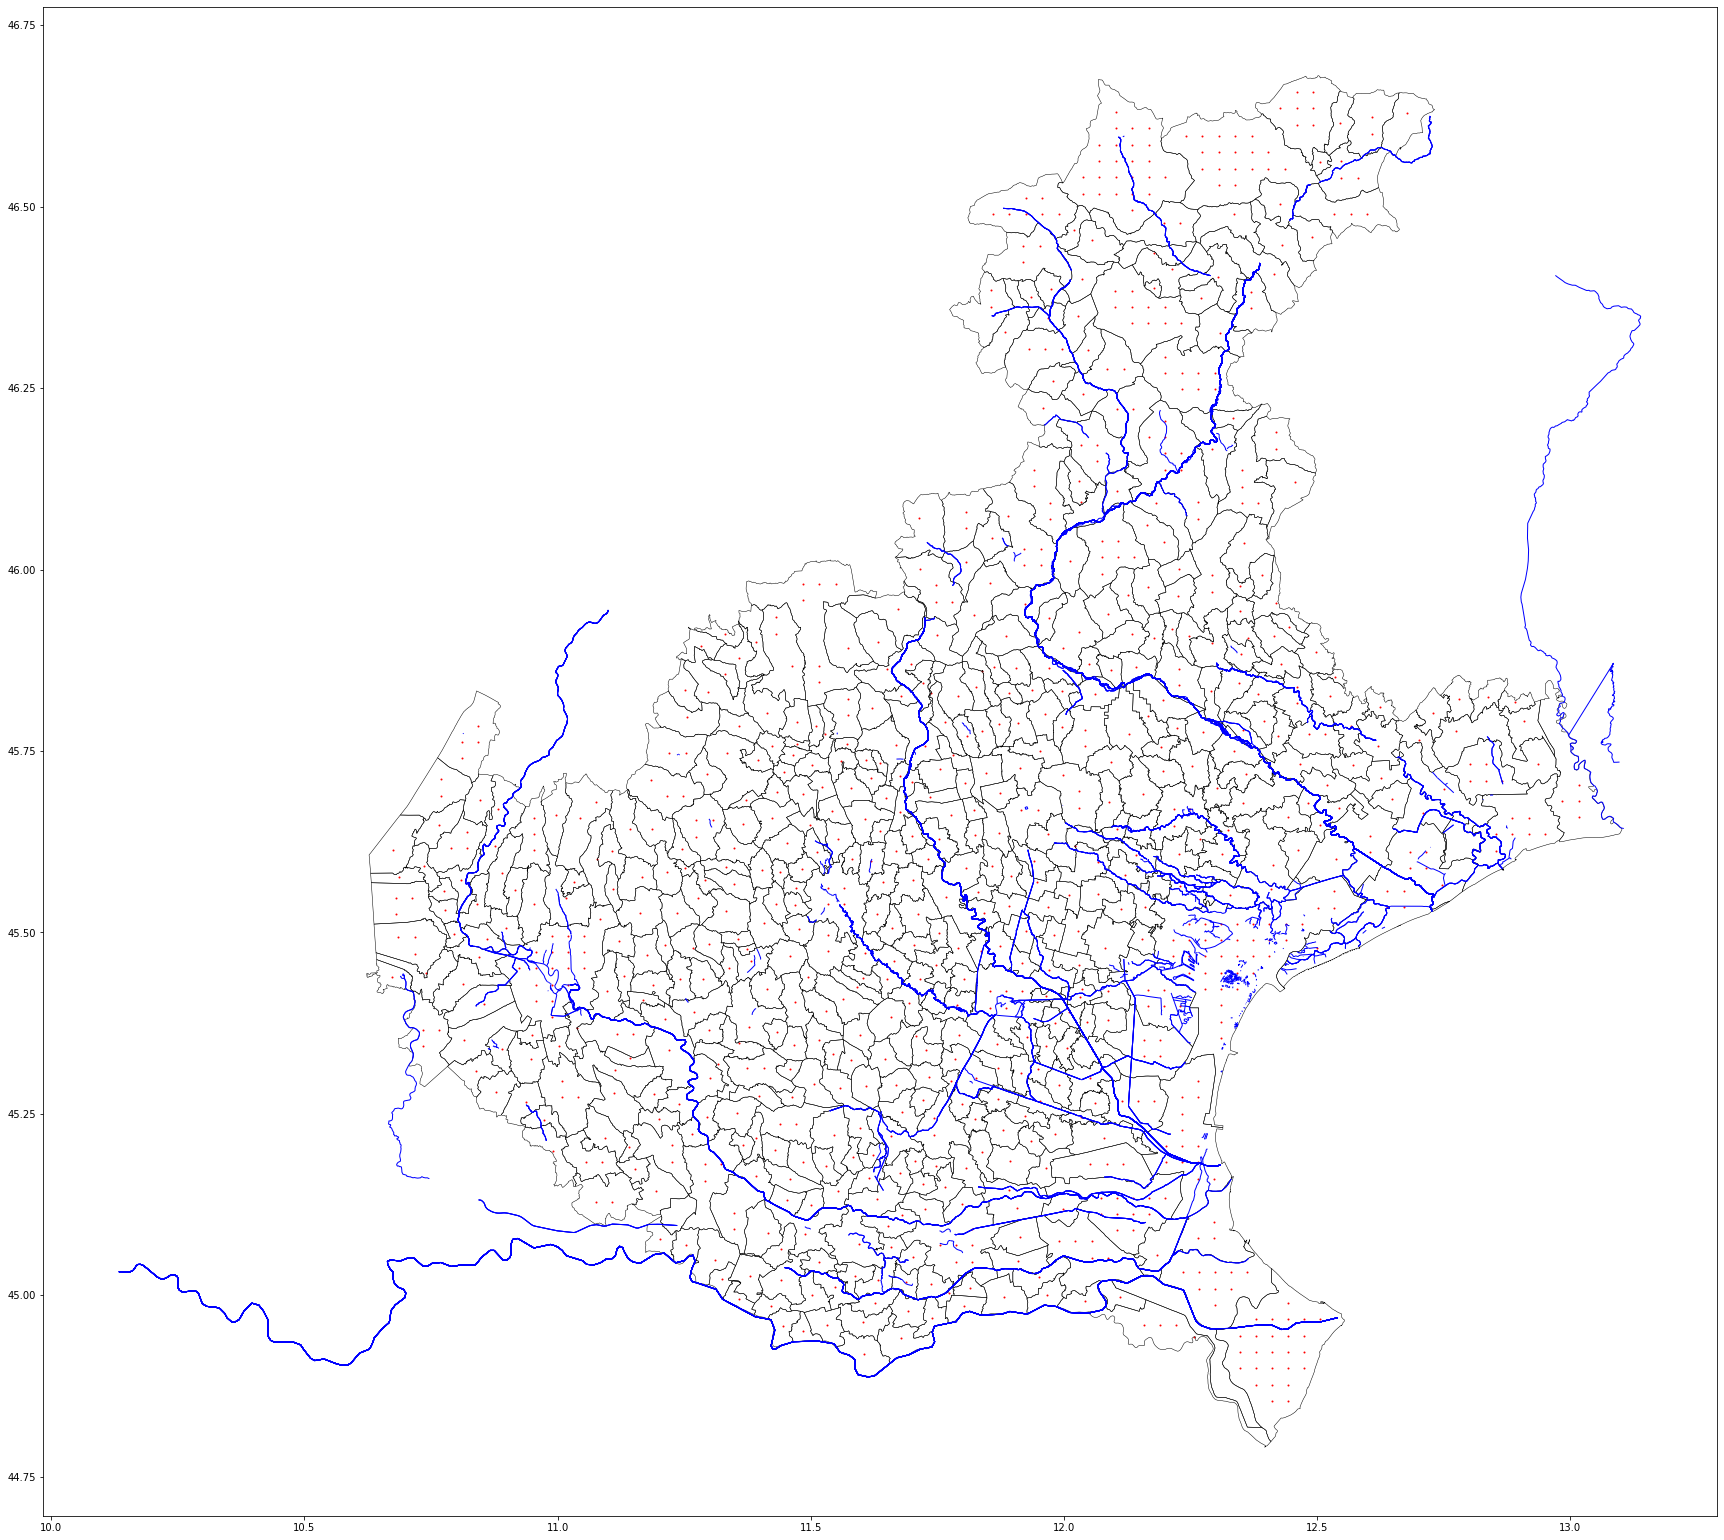

In [67]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [68]:
value_counts = nuts2_grid['lau1'].value_counts().sort_values()

In [69]:
arr = value_counts.values

In [70]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [71]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [72]:
value_counts_target

erbezzo                1
rubano                 1
isola vicentina        1
cittadella             1
conegliano             1
                      ..
auronzo da cadore      8
verona                 8
cortina da ampezzo    10
porto tolle           11
venezia               16
Length: 571, dtype: int32

In [73]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: saint dona da piave || Value: 2 || Target Value: 1
Index: arcugnano || Value: 2 || Target Value: 1
Index: zevio || Value: 2 || Target Value: 1
Index: cerea || Value: 2 || Target Value: 1
Index: perarolo da cadore || Value: 2 || Target Value: 1
Index: vittorio veneto || Value: 2 || Target Value: 1
Index: trichiana || Value: 2 || Target Value: 1
Index: la valle agordina || Value: 2 || Target Value: 1
Index: valdobbiadene || Value: 2 || Target Value: 1
Index: bosco chiesanuova || Value: 2 || Target Value: 1
Index: monselice || Value: 2 || Target Value: 1
Index: gazzo veronese || Value: 2 || Target Value: 1
Index: montagnana || Value: 2 || Target Value: 1
Index: villa bartolomea || Value: 2 || Target Value: 1
Index: nogara || Value: 2 || Target Value: 1
Index: brenzone sul garda || Value: 2 || Target Value: 1
Index: lusiana || Value: 2 || Target Value: 1
Index: susegana || Value: 2 || Target Value: 1
Index: portogruaro || Value: 2 || Target Value: 1
Index: saint pietro da cadore || 

In [74]:
to_remove = pd.Series(data=points, index=idx)

In [75]:
to_remove

saint dona da piave     1
arcugnano               1
zevio                   1
cerea                   1
perarolo da cadore      1
                       ..
auronzo da cadore      10
verona                 11
cortina da ampezzo     14
porto tolle            15
venezia                21
Length: 84, dtype: int64

In [76]:
# indicies_to_remove = []

# for municipality, points in to_remove.iteritems():
#     indicies = nuts2_grid.loc[nuts2_grid['lau1'] ==  municipality].index.tolist()
#     to_removed = random.sample(indicies, points)
#     for item in to_removed:
#         indicies_to_remove.append(item)

# nuts2_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
# nuts2_grid.reset_index(inplace = True, drop = True)

In [77]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

<AxesSubplot:>

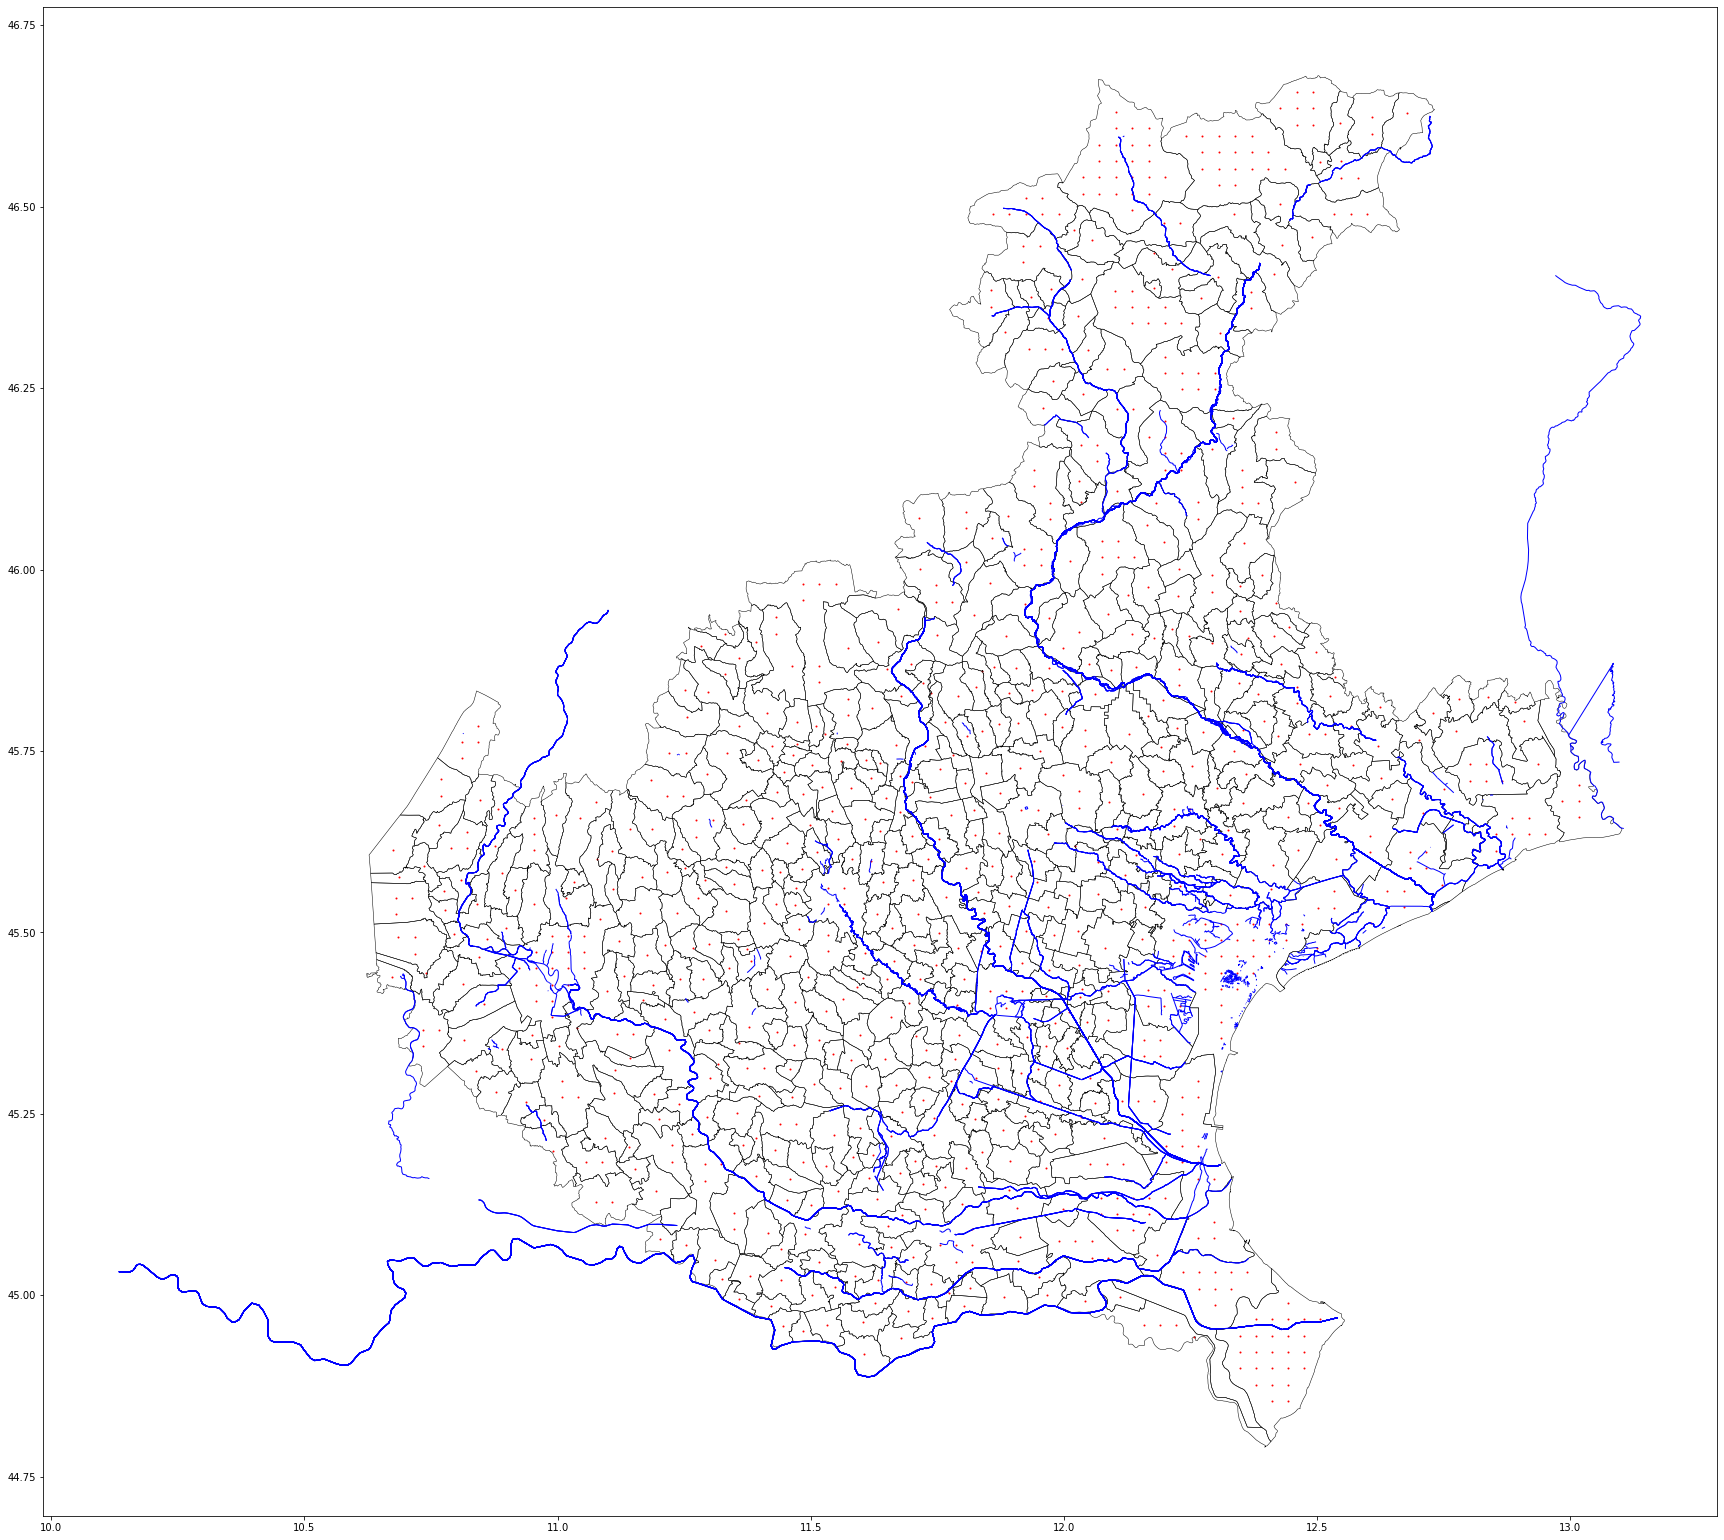

In [78]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [79]:
len(nuts2_grid['lau1'].unique())

571

In [80]:
nuts2_grid

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((11.31808 45.28770, 11.31808 45.31016...",albaredo da adige,11.30213,45.29893,veneto,POINT (11.30213 45.29893)
1,"POLYGON ((11.20247 45.63108, 11.20247 45.65353...",crespadoro,11.18641,45.64230,veneto,POINT (11.18641 45.64230)
2,"POLYGON ((10.87121 45.38996, 10.87121 45.41242...",sommacampagna,10.85523,45.40119,veneto,POINT (10.85523 45.40119)
3,"POLYGON ((11.29043 45.62090, 11.29043 45.64336...",valdagno,11.27438,45.63213,veneto,POINT (11.27438 45.63213)
4,"POLYGON ((11.29043 45.64336, 11.29043 45.66582...",valdagno,11.27438,45.65459,veneto,POINT (11.27438 45.65459)
...,...,...,...,...,...,...
898,"POLYGON ((11.19826 45.25346, 11.19861 45.25216...",saint pietro da morubio,11.20096,45.24276,veneto,POINT (11.20096 45.24276)
899,"POLYGON ((12.06082 46.33488, 12.06161 46.33485...",agordo,12.04755,46.30297,veneto,POINT (12.04755 46.30297)
900,"POLYGON ((11.75146 45.87320, 11.75260 45.87308...",pove da grappa,11.73823,45.83013,veneto,POINT (11.73823 45.83013)
901,"POLYGON ((11.68538 45.70087, 11.68542 45.70001...",pozzoleone,11.67640,45.66637,veneto,POINT (11.67640 45.66637)


In [81]:
final_grid = nuts2_grid[['nuts2', 'lau1', 'x', 'y']].sort_values(by=['lau1'])

In [82]:
final_grid

,nuts2,lau1,x,y
847,veneto,abano terme,11.79324,45.35865
275,veneto,adria,12.05470,45.07423
274,veneto,adria,12.05470,45.05177
273,veneto,adria,12.02294,45.07423
272,veneto,adria,11.99118,45.07423
...,...,...,...,...
317,veneto,zevio,11.14969,45.36071
742,veneto,zimella,11.35805,45.34777
694,veneto,zoppe da cadore,12.17878,46.38835
559,veneto,zovencedo,11.49430,45.43798


In [83]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid.csv', encoding=enc, index = False)